FL Note: This is a sample screen that I have processed. The purpose was to find genes that behave differently in underlying backgrounds. Essentially, this analysis can be summarized in the following steps: <br>**1)** Performing the biological experiment and evaluating the quality of the data.<br> **2)** Processing the raw data through software to interpret biological fitness attributed to single genes.<br> **3)** Normalize data and perform SVD (matrix factorization technique) to identify genes the perform differently in backgrounds.<br> **4)** Analysis genes behaving differently and see if its real biology!

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
#loading in libraries
import pandas as pd
import scipy.stats as stats
import scipy.cluster.hierarchy as clust
import matplotlib.pyplot as plt
import coessentiality as coes
import re
import csv
import os as os
import seaborn as sns

import glob

## Quality Control of Underlying Data

In [3]:
#looking at the raw data
reads = pd.read_table('./data/HCT116_Combined_FANCKO_Raw_Reads.txt', index_col=0)
sample_sum = reads.iloc[:,range(1,22)].sum(0)
reads.head()

,GENE,FANCG_T1_1,FANCG_T1_2,FANCG_T1_3,FANCL_T1_1,FANCL_T1_2,FANCL_T1_3,WT_T1_1,WT_T1_2,WT_T1_3,...,FANCG_T2_2,FANCG_T2_3,FANCL_T0,FANCL_T2_1,FANCL_T2_2,FANCL_T2_3,WT_T0,WT_T2_1,WT_T2_2,WT_T2_3
GENE_CLONE,,,,,,,,,,,,,,,,,,,,,
A1BG_ACTGGCGCCATCGAGAGCCA,A1BG,116,128,111,55,106,124,89,75,51,...,37,95,199,13,45,73,183,41,81,51
A1BG_CAAGAGAAAGACCACGAGCA,A1BG,805,799,440,397,484,449,540,720,552,...,380,444,825,301,377,284,840,452,431,230
A1BG_GCTCAGCTGGGTCCATCCTG,A1BG,534,708,302,255,325,492,380,784,362,...,217,162,504,198,184,236,769,237,219,182
A1BG_GTCGAGCTGATTCTGAGCGA,A1BG,517,629,381,254,214,300,352,474,576,...,279,248,446,157,178,98,404,217,168,271
A1CF_AGTTATGTTAGGTATACCCG,A1CF,523,716,365,507,351,496,566,764,726,...,267,464,616,335,284,244,552,349,297,413


In [4]:
sample_sum

FANCG_T1_1    39700232
FANCG_T1_2    43465958
FANCG_T1_3    24046066
FANCL_T1_1    24405222
FANCL_T1_2    21400075
FANCL_T1_3    36477460
WT_T1_1       36231076
WT_T1_2       39303135
WT_T1_3       37369262
FANCG_T0      37573141
FANCG_T2_1    22494062
FANCG_T2_2    16389479
FANCG_T2_3    18105366
FANCL_T0      35743169
FANCL_T2_1    17857102
FANCL_T2_2    16973170
FANCL_T2_3    15956400
WT_T0         43192345
WT_T2_1       22414184
WT_T2_2       18996888
WT_T2_3       18594938
dtype: int64

**QC Step:** Do we have enough reads?

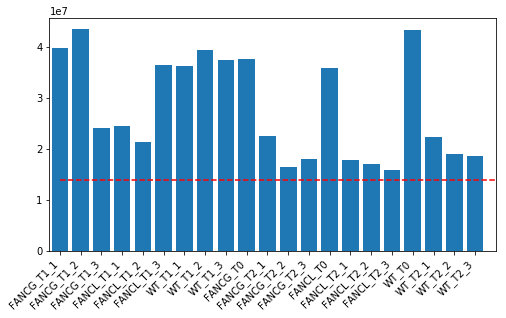

In [5]:
#bar plot looking at the total overall number of reads

figure( figsize(8,6))
bar( arange(len(sample_sum)), sample_sum, align='center')
plot( [0, len(sample_sum)], [14e6, 14e6], 'r--')
xlim(-0.5, len(sample_sum))
xticks(arange(len(sample_sum)), reads.columns.values[1:],fontsize =10, rotation=45,ha='right',va='top')
subplots_adjust(bottom=0.34)
sample_sum
show()

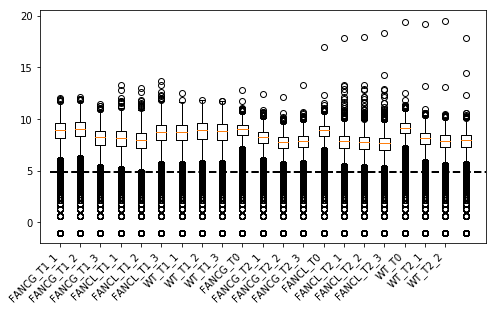

In [6]:
#boxplots looking at the distribution of reads per gene

figure(figsize(8,6))
boxplot(log2(asarray(reads.iloc[:,1:])+0.5))
plot([0.5, len(sample_sum)+1], log2([30, 30]), 'k--', linewidth=2)
xlim(0, len(sample_sum)+1)
xticks(arange(1,len(sample_sum)), reads.columns.values[1:], rotation=45,ha='right')
subplots_adjust(bottom=0.34)
#savefig('boxplots-hap1-read-distributions.pdf')
show()

**Processing Data Step:** We have sufficient number of reads, we can process through existing software (BAGEL - a bayesian classifier of gene fitness). This transforms the reads into a new value.

In [7]:
#First Calculate the Log2 Fold Change - a raw score of genetic fitness in screens. 
!./BAGEL.py fc -i ./data/HCT116_Combined_FANCKO_Raw_Reads.txt -o ./data/FancG_HCT116 -c FANCG_T0;
!./BAGEL.py fc -i ./data/HCT116_Combined_FANCKO_Raw_Reads.txt -o ./data/FancL_HCT116 -c FANCL_T0
!./BAGEL.py fc -i ./data/HCT116_Combined_FANCKO_Raw_Reads.txt -o ./data/WT_HCT116 -c WT_T0

Controls: FANCG_T0
Controls: FANCL_T0
Controls: WT_T0


In [8]:
#Calculate the bayes factors - a probability score of genetic fitness based on prior distributions. 
!./BAGEL.py bf -i ./data/FancG_HCT116.foldchange -e ./CEGv2.txt -n ./NEGv1.txt -o ./data/Bagel_FancG_HCT116_T1 -c FANCG_T1_1,FANCG_T1_2,FANCG_T1_3
!./BAGEL.py bf -i ./data/FancG_HCT116.foldchange -e ./CEGv2.txt -n ./NEGv1.txt -o ./data/Bagel_FancG_HCT116_T2 -c FANCG_T2_1,FANCG_T2_2,FANCG_T2_3
!./BAGEL.py bf -i ./data/FancL_HCT116.foldchange -e ./CEGv2.txt -n ./NEGv1.txt -o ./data/Bagel_FancL_HCT116_T1 -c FANCL_T1_1,FANCL_T1_2,FANCL_T1_3
!./BAGEL.py bf -i ./data/FancL_HCT116.foldchange -e ./CEGv2.txt -n ./NEGv1.txt -o ./data/Bagel_FancL_HCT116_T2 -c FANCL_T2_1,FANCL_T2_2,FANCL_T2_3
!./BAGEL.py bf -i ./data/WT_HCT116.foldchange -e ./CEGv2.txt -n ./NEGv1.txt -o ./data/Bagel_WT_HCT116_T1 -c WT_T1_1,WT_T1_2,WT_T1_3
!./BAGEL.py bf -i ./data/WT_HCT116.foldchange -e ./CEGv2.txt -n ./NEGv1.txt -o ./data/Bagel_WT_HCT116_T2 -c WT_T2_1,WT_T2_2,WT_T2_3


Using column:  FANCG_T1_1, FANCG_T1_2, FANCG_T1_3
Number of unique genes:  18053
Number of reference essentials: 684
Number of reference nonessentials: 928
Iter TrainEss TrainNon TestSet
0 588 719 1806
1 584 719 1806
2 575 729 1806
3 591 708 1805
4 581 712 1805
5 577 718 1805
6 591 718 1805
7 567 722 1805
8 578 725 1805
9 582 703 1805
Using column:  FANCG_T2_1, FANCG_T2_2, FANCG_T2_3
Number of unique genes:  18053
Number of reference essentials: 684
Number of reference nonessentials: 928
Iter TrainEss TrainNon TestSet
0 576 719 1806
1 566 710 1806
2 576 697 1806
3 591 703 1805
4 583 714 1805
5 581 721 1805
6 583 716 1805
7 593 726 1805
8 590 730 1805
9 575 737 1805
Using column:  FANCL_T1_1, FANCL_T1_2, FANCL_T1_3
Number of unique genes:  18053
Number of reference essentials: 684
Number of reference nonessentials: 928
Iter TrainEss TrainNon TestSet
0 587 722 1806
1 574 705 1806
2 581 724 1806
3 586 724 1805
4 576 712 1805
5 572 723 1805
6 590 733 1805
7 582 708 1805
8 576 711 1805
9 59

In [9]:
#Parsing data all together
BF_list=glob.glob('./data/Bagel_*')
BFs_s=pd.read_table(BF_list[0])
sample=BF_list[0].split('./data/Bagel_')[1]
BFs_s.rename(columns={'BF':sample},inplace=True)
BFs_s.head()
for i in range(1,len(BF_list)):
    table_s=pd.read_table(BF_list[i])
    BFs_s['BF']=table_s.BF
    sample=BF_list[i].split('./data/Bagel_')[1]
    BFs_s.rename(columns={'BF':sample},inplace=True)
BFs_s.to_csv('./data/BF_all.txt',sep='\t',index=False) 

**QC Step:** We have evaluated the incoming data, now we have to evaluate the experiment itself. Do the samples behave similarly?

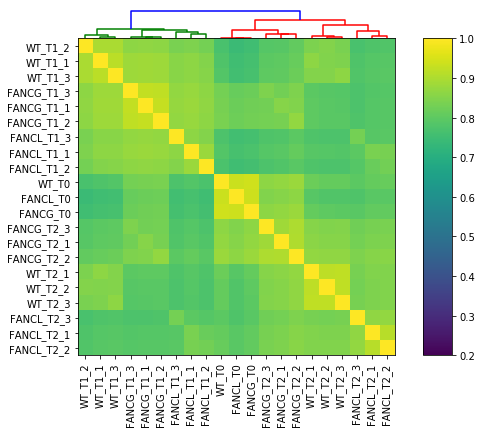

In [10]:
#Normalized read count data - This is another QC step

normed = pd.read_table('./data/FancG_HCT116.normed_readcount', sep='\t', index_col=0)
normed1 = log2( normed + 0.5 )
cc1 = normed1.corr()

Y  = clust.linkage( cc1 , method='average', metric='correlation')

f=figure( figsize(8,8))

# DENDROGRAM
axdend   = f.add_axes([0.25,0.85,0.55,0.05])
Z = clust.dendrogram( Y, orientation='top' )
axdend.set_yticks([])
idx = Z['leaves']
coes.clean_axis(axdend)

# HEATMAP
plotMatrix = cc1.values[:,idx]
plotMatrix = plotMatrix[idx,:]

axmatrix = f.add_axes([0.25,0.30,0.55,0.55])
im = axmatrix.matshow( plotMatrix, aspect='auto', vmin=0.2, vmax=1.0)
axmatrix.set_xticks([])
axmatrix.xaxis.set_ticks_position('bottom')
axmatrix.yaxis.set_ticks_position('left')
axmatrix.set_yticks(range(cc1.shape[0]))
axmatrix.set_xticks(range(cc1.shape[0]))
axmatrix.set_xticklabels(cc1.columns.values[idx], rotation=90)
axmatrix.set_yticklabels(cc1.columns.values[idx])

cbar = f.add_axes([.85,.30,.05,.55])
colorbar(im, cax=cbar)
#savefig('./fig/Correlation-hct-stress-lib.png',format='png',dpi=500)
show()

**QC Step:** Checking reference distributions. This is the prior distribution for the bayesian classifier.

In [11]:
fc = pd.read_table('./data/FancG_HCT116.foldchange')
fc = fc.drop(['REAGENT_ID'],axis =1)
#fc

In [12]:
ess = pd.read_table('./CEGv2.txt', index_col=0)
non = pd.read_table('./NEGv1.txt', index_col=0)

In [13]:
essidx = find( in1d(fc.GENE, ess.index.values))
nonidx = find( in1d(fc.GENE, non.index.values))
#print essidx.shape()
#print nonidx.shape()

In [14]:
essidx.shape

(2534,)

In [15]:
nonidx.shape

(3076,)

**QC Step:** Checking for differences in curves. If we see differences between peaks, then the experiment is working.

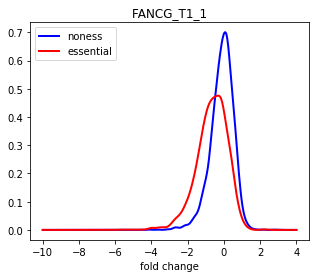

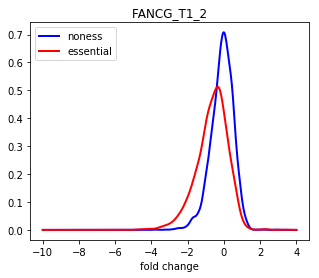

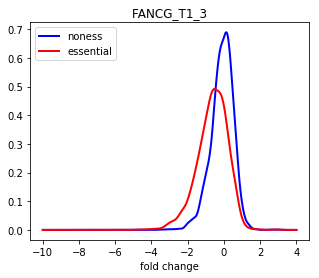

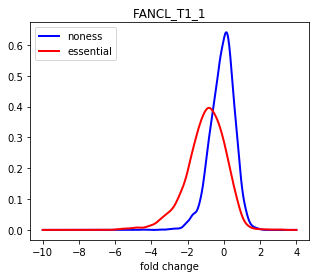

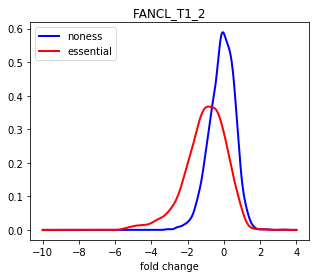

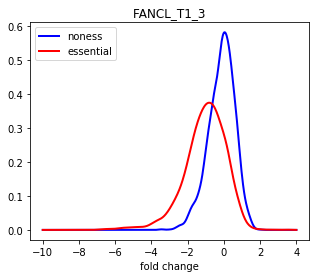

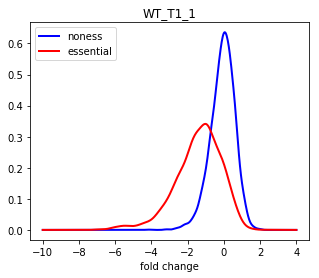

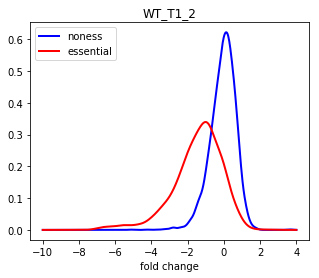

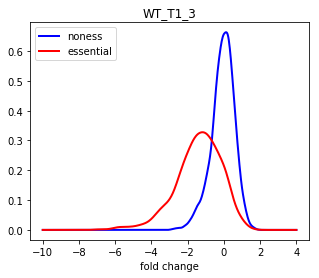

In [16]:
for i in range(1,10):
    xx = linspace(-10,4,500)
    #i=3
    sample = fc.columns.values[i]
    kess = stats.gaussian_kde( fc.loc[essidx,sample])
    knon = stats.gaussian_kde( fc.loc[nonidx,sample])
    figure( figsize(5,4))
    plot( xx, knon.evaluate(xx), c='b', linewidth=2, label='noness')
    plot( xx, kess.evaluate(xx), c='r', linewidth=2, label='essential')
    legend(loc=2)
    xlabel('fold change')
    title(sample)
    #savefig('./fig/%s_Empirical density_.png'%(sample),format='png',dpi=500)
    show()

In [17]:
def draw_prcurve(positive, negative, data, target, ax=None,figsize=(8,6),linewidth=3):
    
    data = data.sort_values(by=target,ascending=False)
    data_pr = pd.DataFrame(index=data.index, columns=['Precision','Recall'])
    ## calculate pr

    TP = 0
    FP = 0
    FN = len(positive)
    prepre = 1.0
    prerec = 0.0
    precision = 1.0
    recall = 0.0
    APR = 0.0

    ## for true identification
    TRAINTP = 0
    TRAINTN = 0

    for index,row in data.iterrows():
        gene = index
        bf = row[target]
        if gene in positive:
            TP += 1
            FN -= 1
            if bf > 0:
                TRAINTP += 1
        elif gene in negative:
            FP += 1
            if bf < 0:
                TRAINTN += 1
        #print "%f\t%f"%(precision,recall)
        if TP!=0:
            precision = float(TP / float(TP+FP))
            recall = float(TP/float(TP+FN))
        if recall != prerec:
            APR += (recall - prerec) * (  0.5 * (precision + prepre) )
            prepre = precision
            prerec = recall
        data_pr.loc[gene]['Precision'] = precision
        data_pr.loc[gene]['Recall'] = recall
        #print gene + "\t" + str(bf) + "\t%f\t%f"%(precision,recall)

    if recall != 1.0:
        APR += (1.0 - prerec) * ( 0.5 * prepre )

    #print target + "\t" + str(APR)
    df = pd.DataFrame(data_pr.loc[:,['Recall','Precision']])
    ax = df.plot.line(ax = ax, x='Recall',y='Precision', figsize=figsize,linewidth=linewidth)
    return ax, APR
    

**QC Step:** Making a PR Curve from the resulting data. PR Curve chosen over ROC curve, because we are not interested in FPR. More interested in positive predictions.

FancG_HCT116_T1	0.826311425590755
FancG_HCT116_T2	0.9444966977915291
FancL_HCT116_T1	0.9309422734951637
FancL_HCT116_T2	0.9712550405262046
WT_HCT116_T1	0.9692707949322142
WT_HCT116_T2	0.9887888327990432


"\napr_df = pd.DataFrame(index = apr_bf.keys())\napr_df['BF_string'] = pd.DataFrame.from_dict(apr_bf,orient='index')\napr_df['NBF_string'] = pd.DataFrame.from_dict(apr_nbf,orient='index')\n"

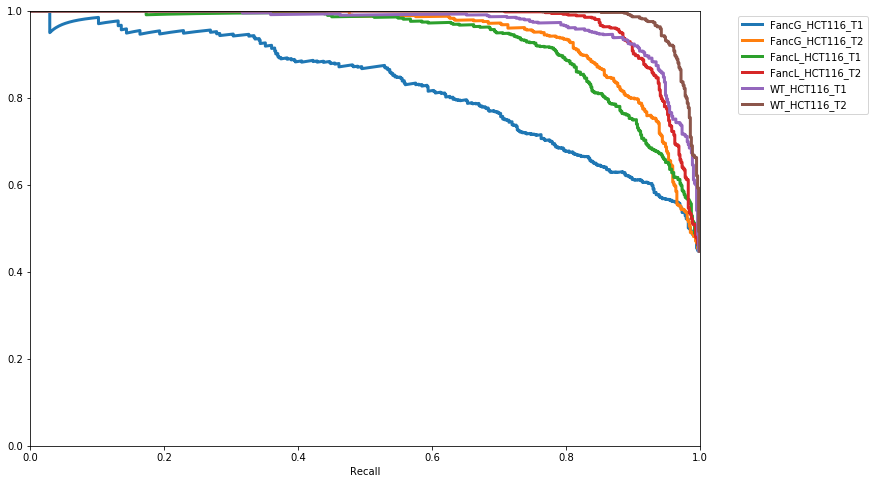

In [18]:
## load ess, noness

esstable = pd.read_table("./CEGv2.txt",header = 0,index_col=False)
nonesstable = pd.read_table("./NEGv1.txt", header = 0, index_col = False)
data = pd.read_table("./data/BF_all.txt",header=0,index_col=0)
apr_bf=dict()
apr_nbf=dict()
legends=list()

plt.figure(figsize=(10,10))
ax=None
for cell_line in data:
    
    ## filtering training set out which are not in bf list
    positive = list()
    negative = list()

    for gene in esstable['GENE'].tolist():
        if gene in data.index.tolist():
            positive.append(gene)
    for gene in nonesstable['GENE'].tolist():
        if gene in data.index.tolist():
            negative.append(gene)

    ax,apr_bf[cell_line] = draw_prcurve(positive,negative, data,cell_line,figsize=(12,8),ax=ax)
    print(cell_line + "\t" + str(apr_bf[cell_line]))
    
    legends.append(cell_line)
    
ax.legend(legends,bbox_to_anchor=(1.05, 1), loc=2,prop={'size':10}) 
plt.ylim(0,1)
plt.xlim(0,1)
        
'''
apr_df = pd.DataFrame(index = apr_bf.keys())
apr_df['BF_string'] = pd.DataFrame.from_dict(apr_bf,orient='index')
apr_df['NBF_string'] = pd.DataFrame.from_dict(apr_nbf,orient='index')
'''
#plt.savefig("./Figs/Screen_PR_Curves.pdf", bbox_inches='tight')

In [19]:
bf = pd.read_table('./data/BF_all.txt', index_col=0)
#bf.drop(['luciferase','LacZ','EGFP'], inplace=True)
bf.head()

,FancG_HCT116_T1,FancG_HCT116_T2,FancL_HCT116_T1,FancL_HCT116_T2,WT_HCT116_T1,WT_HCT116_T2
GENE,,,,,,
A1BG,-3.153,-1.133,-2.471,7.734,-5.521,-3.290
A1CF,-8.273,-20.660,-0.744,0.058,1.459,-1.671
A2M,-1.279,-2.992,-12.231,-22.780,-14.874,-23.120
A2ML1,-1.902,-11.437,-10.704,-28.357,-11.398,-26.176
A3GALT2,-9.726,-17.423,-10.016,-9.736,-20.547,-19.016


## Evaluating the Biological Results

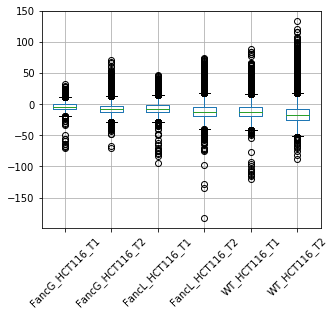

In [20]:
bf.dropna(inplace=True)
bf.boxplot(rot=45)

In [21]:
# quantile normalize
#
rank_mean = bf.stack().groupby(bf.rank(method='first').stack().astype(int)).mean()
qbf = bf.rank(method='min').stack().astype(int).map(rank_mean).unstack()

**Normalization Step:** We normalized the data previously, but now we are interested in normalizing the results. We chose to use quantile normalization (similar to a rank normalization) in order to have identical score distributions. 

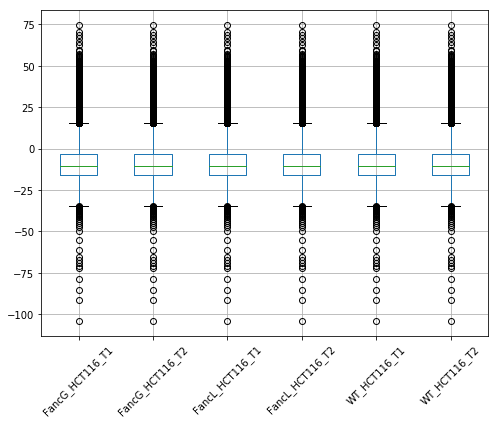

In [22]:
figure(figsize(8,6))
qbf.boxplot(rot=45)

**Normalization Step:** Do our screens look somewhat similar? Blobs are okay. Just want to see reasonable correlation. Outliers will make these plots look skewed.

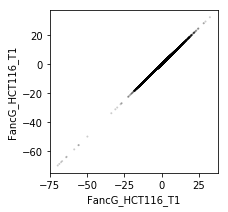

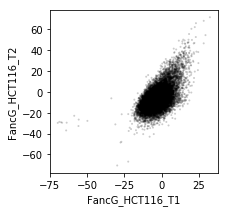

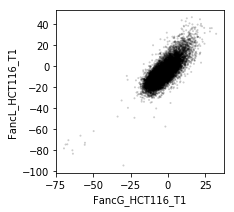

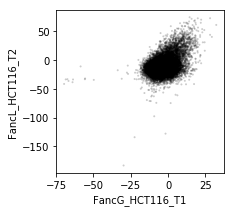

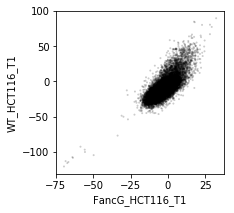

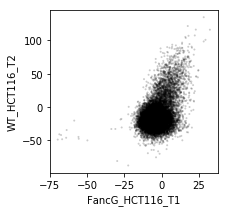

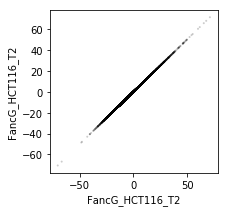

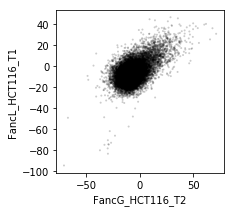

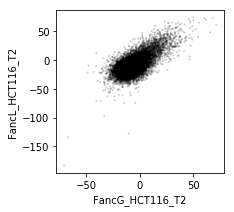

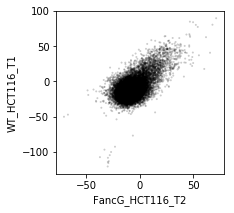

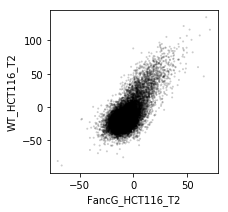

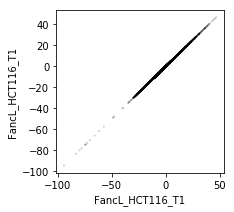

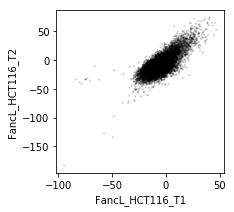

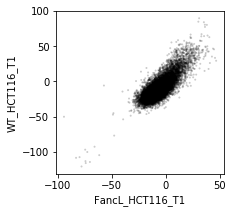

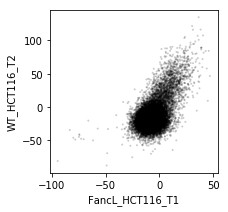

In [23]:
#for i in range(len(qbf.columns)):
for i in range(3):
    for j in range(i,len(qbf.columns)):
        figure( figsize(3,3))
        scatter( bf[bf.columns.values[i]], bf[bf.columns.values[j]], s=4, edgecolor='none', c='k', alpha=0.2)
        xlabel(bf.columns.values[i])
        ylabel(bf.columns.values[j])
        show()

In [24]:
u,s,v = linalg.svd(qbf, full_matrices=0)

**SVD Analysis:** Compare backgrounds against each other. The output matrix v can be used to identify differences and consistencies between samples in the input matrix, while matrix u can indicate which specific rows are contributing to differences observed in matrix v. How do components seperate these our tested backgrounds? 

In [25]:
s**2/sum(s**2)
len(s)

6

**SVD Analysis:** Evaluating the diagonal. Variation contribution for each component. We expect most to be in the first component.

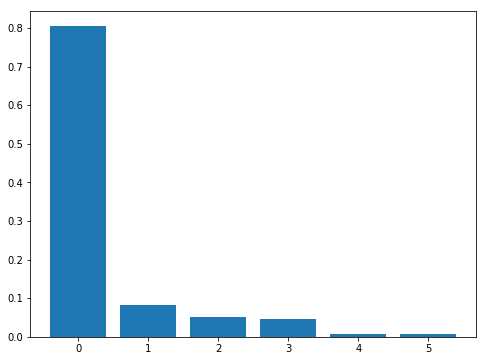

In [26]:
figure(figsize(8,6))
s
s**2 
bar(range(len(s)),s**2/sum(s**2))
show()

**SVD Analysis:** Evaluating the v matrix. This allows us to identify the component which might identify biological differences. The first heatmap shows which samples are contributing to each component. <br> <br> For example, component 2 (row "1") is experimental differences. Notice that the colors seperate based on the time values. Component 4 (row "3") identifies differences between WT (wild-type/ normal cells), vs the Fanc background (background of interest). <br><br> The red heatmap shows how much each sample's variation is lending to the component.

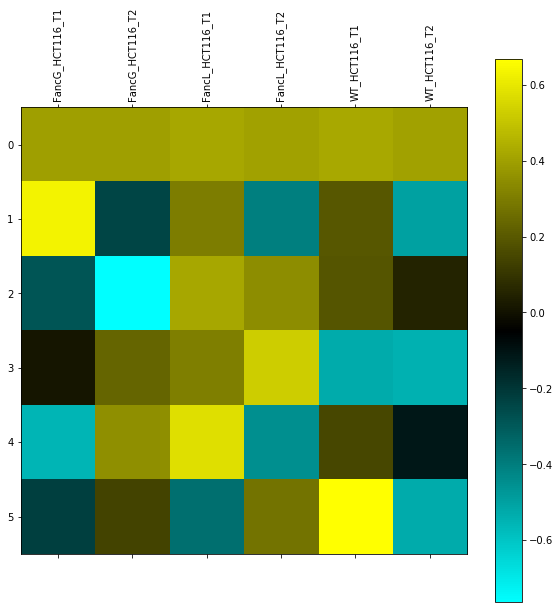

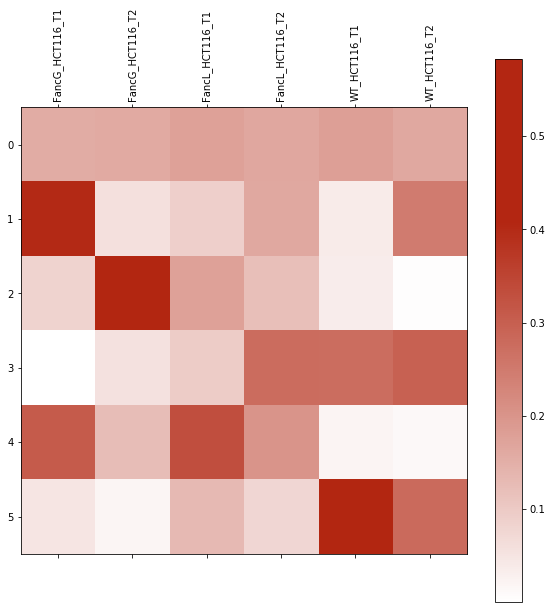

In [27]:
fig = figure( figsize(10,10))
ax = fig.add_subplot(111)
cax = ax.matshow(v, cmap=coes.getYellowCyanGradientCmap())
fig.colorbar(cax)
ax.set_xticks(np.arange(len(qbf.columns)))
ax.set_xticklabels(qbf.columns,visible=True,rotation=90)
show()

fig = figure( figsize(10,10))
ax = fig.add_subplot(111)
cax = ax.matshow(v**2, cmap=coes.getBrickGradientCmap())
fig.colorbar(cax)
ax.set_xticks(np.arange(len(qbf.columns)))
ax.set_xticklabels(qbf.columns,visible=True,rotation=90)
show()

<class 'pandas.core.frame.DataFrame'>
Index: 18053 entries, A1BG to ZZZ3
Data columns (total 6 columns):
U1    18053 non-null float64
U2    18053 non-null float64
U3    18053 non-null float64
U4    18053 non-null float64
U5    18053 non-null float64
U6    18053 non-null float64
dtypes: float64(6)
memory usage: 987.3+ KB


(array([   2.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           1.,    0.,    1.,    0.,    0.,    0.,    0.,    2.,    0.,
           1.,    0.,    1.,    1.,    0.,    1.,    0.,    1.,    4.,
           2.,    5.,    5.,    5.,    9.,    5.,    2.,    8.,   14.,
          12.,   21.,   16.,   28.,   29.,   34.,   33.,   55.,   54.,
          65.,   93.,   81.,  114.,  136.,  156.,  199.,  237.,  262.,
         314.,  358.,  380.,  426.,  443.,  559.,  553.,  634.,  636.,
         718.,  696.,  698.,  741.,  793.,  771.,  723.,  658.,  638.,
         631.,  623.,  567.,  483.,  426.,  375.,  378.,  319.,  308.,
         254.,  202.,  185.,  138.,  122.,   89.,   97.,   75.,   65.,
          46.,   39.,   41.,   21.,   19.,   15.,   22.,   16.,   14.,
           8.,    6.,    4.,    4.,    3.,    5.,    1.,    2.,    0.,
           2.,    1.,    0.,    1.,    4.,    0.,    1.,    2.,    0.,
           0.,    0.,    1.,    0.,    0.,    2.,    0.,    0.,    1.,
      

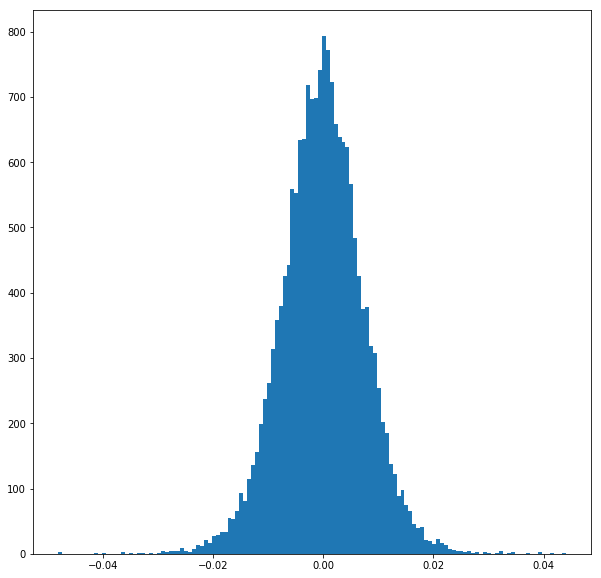

In [28]:
udf = pd.DataFrame(index=bf.index.values)
udf['U1'] = u[:,0]
udf['U2'] = u[:,1]
udf['U3'] = u[:,2]
udf['U4'] = u[:,3]
udf['U5'] = u[:,4]
udf['U6'] = u[:,5]

udf.info()

plt.hist(udf['U4'], bins='auto')

**SVD Analysis:** Component 4 is our component of interest because we see this is where the differential biology measured variation is occuring. 

In [29]:
qbf['U1'] = udf['U1']
qbf['U2'] = udf['U2']
qbf['U3'] = udf['U3']
qbf['U4'] = udf['U4']
qbf['U5'] = udf['U5']
qbf['U6'] = udf['U6']


In [30]:
qbf.sort_values('U4', ascending=False, inplace=True)


**SVD Analysis:** Evaluating a specific set of genes. We don't see too much difference between Fanc and WT samples which is okay.

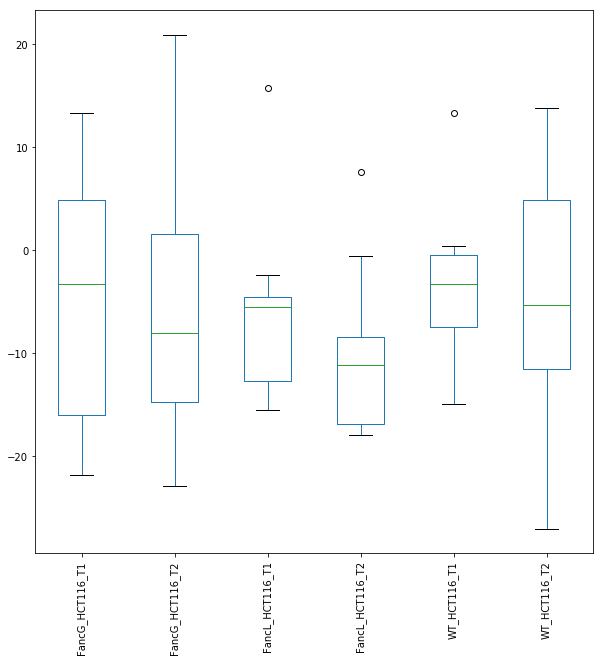

In [31]:
indices = [i for i, s in enumerate(qbf.index) if 'FANC' in s]
fanc = qbf.iloc[indices]
fanc = fanc[fanc.columns.drop(list(fanc.filter(regex='U')))]
fig = plt.figure()
ax = fanc.boxplot(rot = 90)
ax.grid(False)

In [32]:
qbf['mean_WT'] = qbf.loc[:,['WT_HCT116_T1','WT_HCT116_T2']].mean(1)
qbf['mean_FG'] = qbf.loc[:,['FancG_HCT116_T1','FancG_HCT116_T2']].mean(1)
qbf['mean_FL'] = qbf.loc[:,['FancL_HCT116_T1','FancL_HCT116_T2']].mean(1)

**SVD Analysis:** The green gene is particularly interesting because it is in quadrant II and is in our pathway of interest.

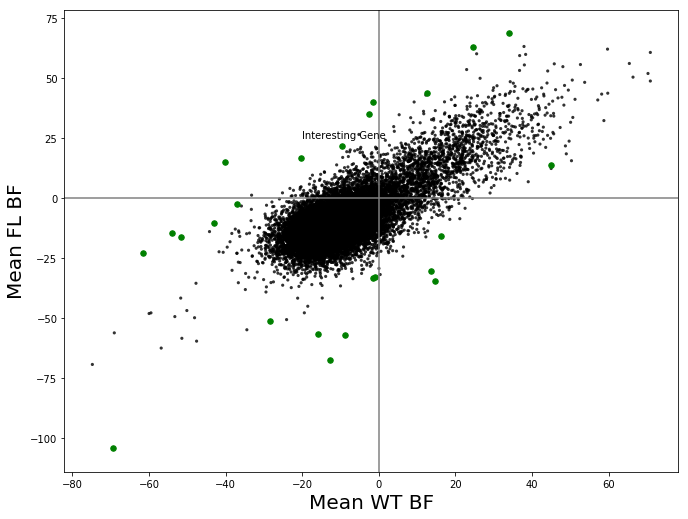

In [33]:
fig = plt.figure(figsize=(11,8.5))
ax = fig.add_subplot(111)

extreme_points = qbf.loc[qbf.U4.abs() > 0.03]
ax.scatter(x = qbf['mean_WT'], y = qbf['mean_FL'], s=10, edgecolor='none', c='k', alpha=0.8)
ax.scatter(extreme_points['mean_WT'], extreme_points['mean_FL'], color='green', label='Extreme Points', s=30)
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

plt.annotate("Interesting Gene", (-20, 25))

ax.set_xlabel('Mean WT BF',size = 20)
ax.set_ylabel('Mean FL BF',size = 20)
show()

In [34]:
gene_val = extreme_points[extreme_points.index == "POLI"]

**Post Analysis:** We compared the gene of interest to other available data. What we see is that its behavior was vastly different. 

In [35]:
POL_BF = pd.read_table('./data/POL_BF_Data.txt', index_col=0)
POL_BF.head()

,CCLE_CELL,BF
GENE,,
POLA2,LS513_LARGE_INTESTINE,5.606
POLB,LS513_LARGE_INTESTINE,-28.534
POLD1,LS513_LARGE_INTESTINE,19.067
POLD2,LS513_LARGE_INTESTINE,17.747
POLD3,LS513_LARGE_INTESTINE,42.357


In [36]:
POL_BF = POL_BF[POL_BF.index == "POLI"]

Text(0,0.5,'Gene of Interest BF')

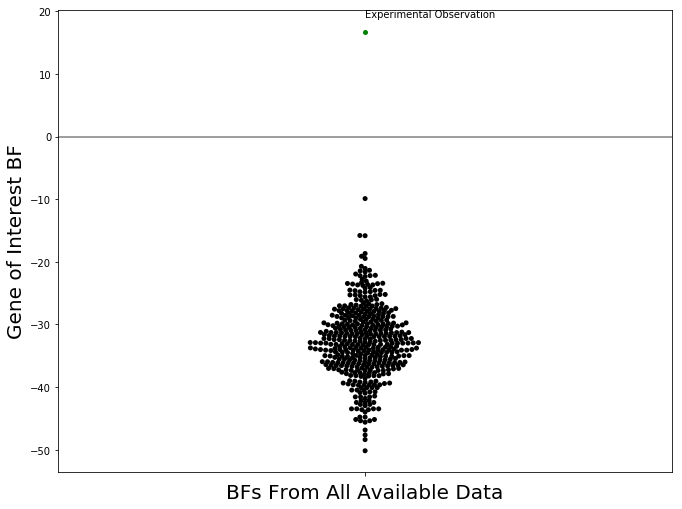

In [37]:
fig = plt.figure(figsize=(11,8.5))
ax = fig.add_subplot(111)

ax = sns.swarmplot(y="BF", data=POL_BF,color = "black")
ax = sns.swarmplot(y="mean_FL",data = gene_val,color = "green")

plt.axhline(0, color='gray')

plt.annotate("Experimental Observation", (0, 19))

ax.set_xlabel('BFs From All Available Data',size = 20)
ax.set_ylabel('Gene of Interest BF',size = 20)
